# Resume Screening – Neural Model Training (GPU)

This notebook trains a deep neural network on structured resume features
to predict shortlisting decisions.


# Imports and devices

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# Load Processed Tensors

In [13]:
X_train = torch.load("../data/processed/X_train.pt").to(device)
X_test  = torch.load("../data/processed/X_test.pt").to(device)
y_train = torch.load("../data/processed/y_train.pt").to(device)
y_test  = torch.load("../data/processed/y_test.pt").to(device)

X_train.shape, y_train.shape


C:\Users\Shubh Agnihotri\AppData\Local\Temp\ipykernel_20992\2584936021.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train = torch.load("../data/processed/X_train.pt

(torch.Size([24000, 6]), torch.Size([24000]))

# Data Loaders

In [14]:
BATCH_SIZE = 256

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)


# Deep MLP

In [15]:
class ResumeNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)
model = ResumeNet(input_dim=6).to(device)
model


ResumeNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

# Loss and Optimizers

In [16]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


# Training Loops

In [17]:
EPOCHS = 20
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f}")


Epoch 01 | Loss: 0.3255
Epoch 02 | Loss: 0.2259
Epoch 03 | Loss: 0.2200
Epoch 04 | Loss: 0.2192
Epoch 05 | Loss: 0.2167
Epoch 06 | Loss: 0.2164
Epoch 07 | Loss: 0.2165
Epoch 08 | Loss: 0.2162
Epoch 09 | Loss: 0.2164
Epoch 10 | Loss: 0.2166
Epoch 11 | Loss: 0.2135
Epoch 12 | Loss: 0.2138
Epoch 13 | Loss: 0.2136
Epoch 14 | Loss: 0.2125
Epoch 15 | Loss: 0.2140
Epoch 16 | Loss: 0.2119
Epoch 17 | Loss: 0.2129
Epoch 18 | Loss: 0.2125
Epoch 19 | Loss: 0.2102
Epoch 20 | Loss: 0.2097


# Loss Curve

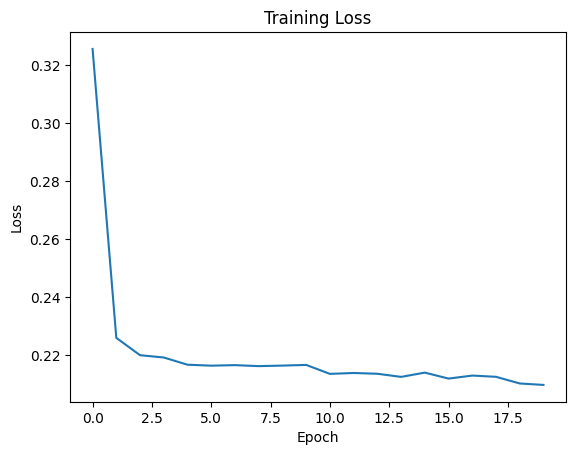

In [18]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


# Evaluation

In [19]:
model.eval()
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).int()

acc = accuracy_score(y_test.cpu(), preds.cpu())
cm  = confusion_matrix(y_test.cpu(), preds.cpu())

acc, cm


(0.9055,
 array([[1507,  300],
        [ 267, 3926]]))

# Save The Model

In [20]:
from pathlib import Path
import os
os.makedirs("../ml/models", exist_ok=True)

torch.save(model.state_dict(), "../ml/models/resume_net.pt")


In [21]:
model = ResumeNet(input_dim=6).to(device)


In [22]:
from pathlib import Path
import torch

MODEL_DIR = Path("../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), MODEL_DIR / "resume_net.pt")

print("✅ Model saved at:", MODEL_DIR / "resume_net.pt")


✅ Model saved at: ..\ml\models\resume_net.pt
